In [1]:
from datasets.bimcvcovid import BIMCVCOVIDDataset
from datasets.bimcvnegative import BIMCVNegativeDataset

seed = 42

pos_ds = BIMCVCOVIDDataset(fold='val', labels='chestx-ray14', random_state=seed)
# neg_ds = BIMCVNegativeDataset(fold='val', labels='chestx-ray14', random_state=seed)

In [2]:
from torchvision.transforms import v2
import torchvision.transforms.functional as F
from torchvision.models.densenet import DenseNet
import torch
import numpy as np
import math
from  monai.transforms import RandSpatialCrop, SpatialPad, RandAffined
from torch import nn

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
NORMALIZED_BLACK = [-0.485/0.229, -0.456/0.224, -0.406/0.225]



def get_transforms(name, abstract_intensity = None):
    if name == 'none': return v2.Identity()

    if name == 'color':
        intensity = 0
        if abstract_intensity == 'weak': intensity = 0.2
        if abstract_intensity == 'medium': intensity = 0.3
        if abstract_intensity == 'strong': intensity = 0.4
        return v2.Compose([
            v2.Lambda(lambda x: denormalize(x)),
            v2.ColorJitter(intensity, intensity, 0, 0),
            v2.Normalize(MEAN, STD),
        ])
    if name == 'affine':
        rot, trans, scale = 0, 0, 1
        if abstract_intensity == 'weak': 
            rot, trans, scale = 0, 0.05, 0
        if abstract_intensity == 'strong':
            rot, trans, scale = 5, 0.1, 0.1
        return v2.RandomAffine(degrees=rot, translate=(trans, trans), scale=(1-scale, 1+scale), fill=NORMALIZED_BLACK)
    if name == 'crop':
        right = 0
        intensity = 0
        if abstract_intensity == 'weak': intensity = 0.15
        if abstract_intensity == 'strong': intensity = 0.25
        if abstract_intensity == 'weak-forced': 
            intensity = 0.15
            right = 0.1
        if abstract_intensity == 'strong-forced': 
            intensity = 0.25
            right = 0.15

        return v2.Compose([
            v2.Lambda(lambda x: denormalize(x)),
            RandSpatialCrop(roi_size=224*(1 - intensity), max_roi_size=224*(1 - right), random_center=False,random_size=True),
            SpatialPad(spatial_size=(224, 224), mode="constant", constant_values=0),
            v2.Normalize(MEAN, STD),
        ])
    if name == 'flip':
        return v2.RandomHorizontalFlip(p=0.5)
    
    
    raise KeyError("incorrect augmentation type")

def denormalize(x):
    _mean = torch.tensor(MEAN)
    _std = torch.tensor(STD)
    
    x = x.permute(1, 2, 0)
    x = _std * x + _mean
    return x.permute(2, 0, 1)

"""
Color Augmentations:
    1. ColorJitter
Geom Augmentations:
    1. RandomHorizontalFlip
    2. RandomRotation
    3. RandomResize
    4. RandomTranslation
    5. RandomCrop
"""
# RandomCrop by translation -> CropPad

def random_crop_by_translation(intensity, preprocessing):
    return v2.Compose([
        v2.RandomAffine(degrees=0, translate=(intensity, intensity), fill=NORMALIZED_BLACK),
        v2.CenterCrop(int(224 * (1-preprocessing))),
        v2.Pad(math.ceil(224 * preprocessing), fill=NORMALIZED_BLACK)
    ])

def color_augmentation(intensity):
    return v2.Compose([
        v2.ColorJitter(brightness=intensity, contrast=intensity),
    ])

def color_visualize(brightness, saturation):
    return v2.Compose([
        v2.Lambda(lambda x: F.adjust_brightness(x, brightness)),
        v2.Lambda(lambda x: F.adjust_contrast(x, saturation)),
    ])

def translate_visualize(translate):
    return v2.Compose([
        v2.Lambda(lambda x: F.affine(x, 0, (translate * 224, translate * 224), 1, 0, 0, fill=0)),
    ])

def scale_visualize(zoom):
    return v2.Compose([
        RandAffined(prob=1.0, scale_range=(0.5, 0.5)),  # Scale randomly
        SpatialPad(spatial_size=(224, 224))  # Ensure fixed size
    ])

def random_compose(augmentations, p=1):
    return v2.Compose([
        v2.RandomApply([auh], p=p) for auh in augmentations
    ])

AUGMENTATION_SETUP = {
    "no_augments": v2.Identity(),
    "baseline-augments": v2.Compose([
        get_transforms('affine', 'weak'),
        get_transforms('color', 'medium'),
        get_transforms('flip'),
    ]),
    "random_crop-weak": v2.Compose([
        get_transforms('crop', 'weak'),
        get_transforms('affine', 'weak'),
        get_transforms('color', 'medium'),
        get_transforms('flip'),
    ]),
    "random_crop-strong": v2.Compose([
        get_transforms('crop', 'strong'),
        get_transforms('affine', 'weak'),
        get_transforms('color', 'medium'),
        get_transforms('flip'),
    ]),
    "random_crop-weak-forced": v2.Compose([
        get_transforms('crop', 'weak-forced'),
        get_transforms('affine', 'weak'),
        get_transforms('color', 'medium'),
        get_transforms('flip'),
    ]),
    "random_crop-strong-forced": v2.Compose([
        get_transforms('crop', 'strong-forced'),
        get_transforms('affine', 'weak'),
        get_transforms('color', 'medium'),
        get_transforms('flip'),
    ]),
    "random_crop-strong-affine": random_compose([
        get_transforms('crop', 'strong'),
        get_transforms('affine', 'strong'),
        get_transforms('color', 'medium'),
        get_transforms('flip'),
    ], 1),
}


VISUALIZATION_SETUP = {
    "NoAugmentations": v2.Identity(),
    "ColorWeakMax": color_visualize(1.2, 1.2),
    "ColorWeakMin": color_visualize(0.8, 0.8),
    "ColorStrongMax": color_visualize(1.4, 1.4),
    "ColorStrongMin": color_visualize(0.6, 0.6),
}

class RandomCenterCrop(nn.Module):
    """
    Randomly crops the center of the image with size between min_scale and max_scale of original size,
    then pads back to original size with normalized black pixels.
    Args:
        min_scale (float): minimum scale of the crop (between 0 and 1)
        max_scale (float): maximum scale of the crop (between 0 and 1)
    """
    def __init__(self, min_scale=0.8, max_scale=1.0):
        super().__init__()
        self.min_scale = min_scale
        self.max_scale = max_scale

    def forward(self, img):
        # Store original size
        _, orig_h, orig_w = img.shape
        
        # Generate random scale between min_scale and max_scale
        scale = torch.empty(1).uniform_(self.min_scale, self.max_scale).item()
        
        # Calculate crop size
        new_h = int(orig_h * scale)
        new_w = int(orig_w * scale)
        
        # Center crop
        cropped = F.center_crop(img, [new_h, new_w])
        
        # Calculate padding
        pad_h = (orig_h - new_h) // 2
        pad_w = (orig_w - new_w) // 2
        
        # Pad back to original size with normalized black
        return F.pad(cropped, 
                    [pad_w, pad_w, pad_h, pad_h], 
                    fill=NORMALIZED_BLACK)

    def __repr__(self):
        return f"{self.__class__.__name__}(min_scale={self.min_scale}, max_scale={self.max_scale})" 

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def show_image(image, title, ax=None):
    """Display an image on a given matplotlib axis with label and path info
    
    Args:
        image (torch.Tensor): Image tensor in CxHxW format
        label (torch.Tensor): One-hot encoded label tensor
        path (str): Path to image file
        ax (matplotlib.axes.Axes, optional): Axis to plot on. If None, uses current axis
    """
    if ax is None:
        ax = plt.gca()
    if len(image.shape) == 4: image = image[0]
    img = image.numpy().transpose((1, 2, 0))  # numpy is [h, w, c] 
    _mean = np.array(mean)  # mean of your dataset
    _std = np.array(std)  # std of your dataset
    img = _std * img + _mean
    
    ax.imshow(img.clip(0, 1))
    ax.set_title(title)
    ax.axis('off')


def denormalize(img):
    img = img.permute((1, 2, 0))  # numpy is [h, w, c] 
    _mean = torch.tensor(mean)  # mean of your dataset
    _std = torch.tensor(std)  # std of your dataset
    img = _std * img + _mean
    return img.permute(2, 0, 1)

torch.Size([3, 224, 224])

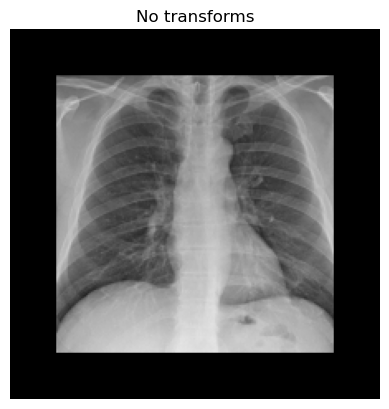

In [4]:
from utils import get_preprocessing

img, y, _, _ = pos_ds.__getitem__(0)
# path = padchest_ds.df.path.iloc[0].split('/')[-1]
# show_image(img, y, "")
preprocessing = get_preprocessing("crop_pad-0.75")
img = preprocessing(img)
show_image(img, "No transforms")
img.shape

In [5]:
from utils import get_preprocessing
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from torchvision.transforms import v2

def visualize_mn_mx_transform(img, transform, intensities):
    fig, axes = plt.subplots(2, len(intensities) // 2, figsize=(12, 8))
    axes = axes.ravel()

    # Get preprocessing transform
    preprocessing = get_preprocessing("crop_pad-0.75")

    # Show images from different datasets
    for i, v in enumerate(intensities):
        img, label, _, _ = pos_ds.__getitem__(0)
        img = preprocessing(img)
        img = denormalize(img)
        img = transform(img, v)
        img = v2.Normalize(mean, std)(img)
        print(img.shape)
        show_image(img, v, axes[i])

    plt.tight_layout()

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


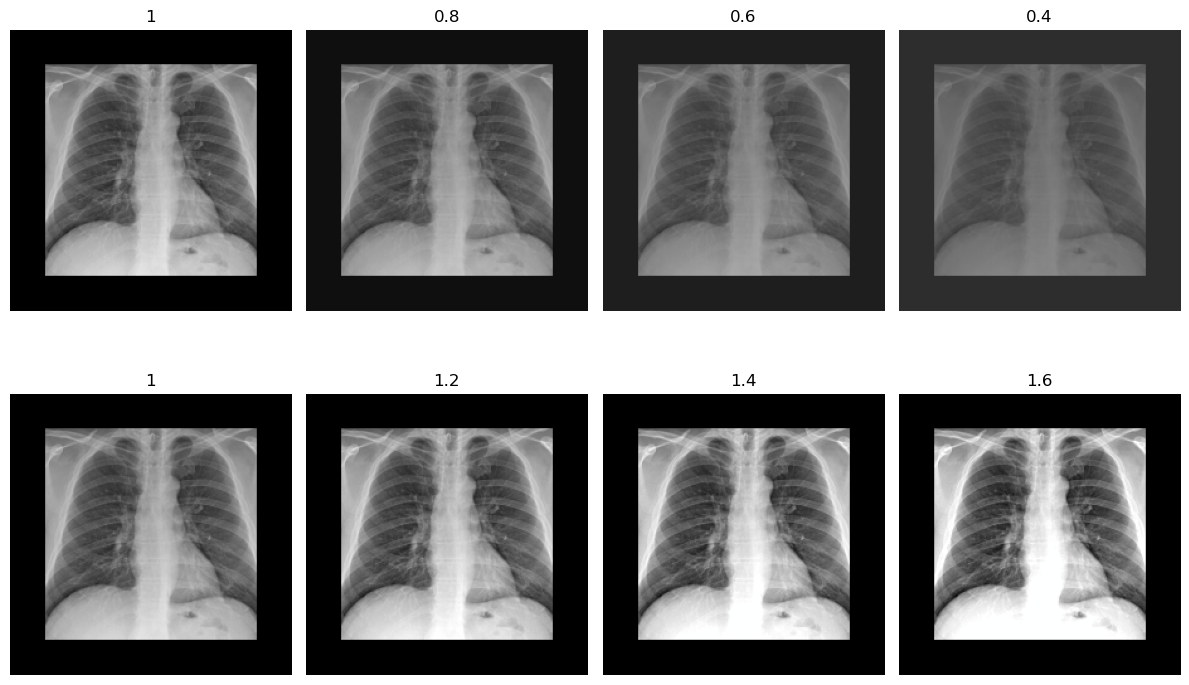

In [6]:
img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.2, 0.4, 0.6]
values = [1 - s for s in strengths] + [1 + s for s in strengths]
visualize_mn_mx_transform(img, F.adjust_contrast, values)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


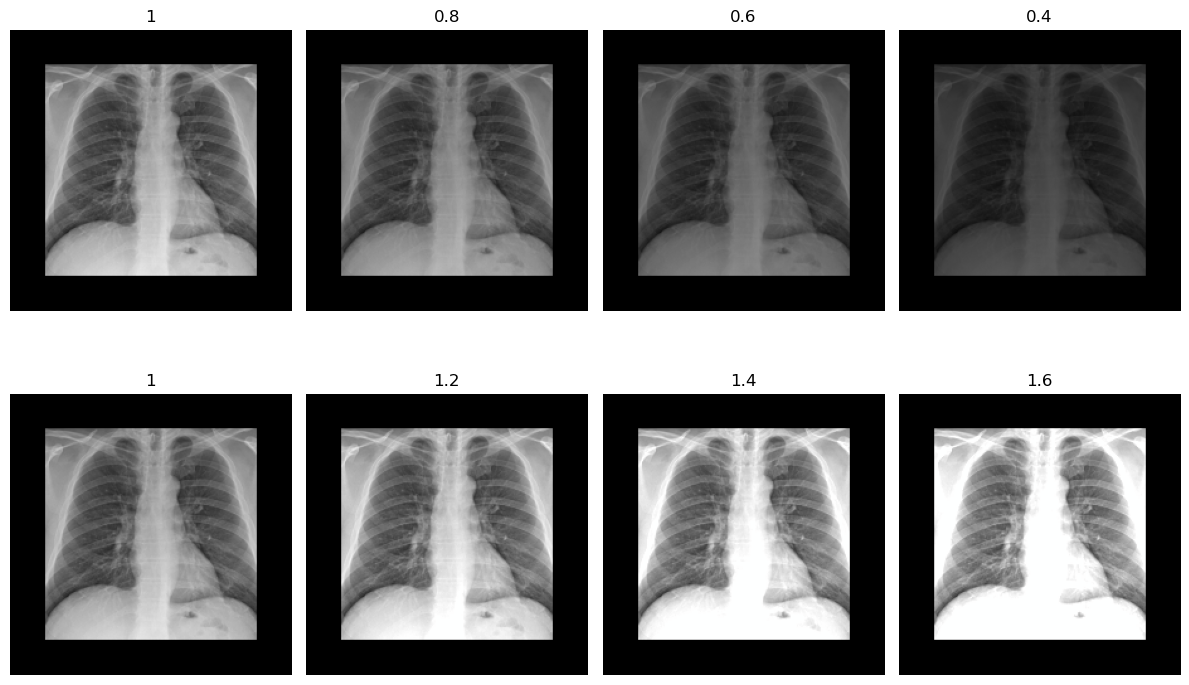

In [7]:
img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.2, 0.4, 0.6]
values = [1 - s for s in strengths] + [1 + s for s in strengths]
visualize_mn_mx_transform(img, F.adjust_brightness, values)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


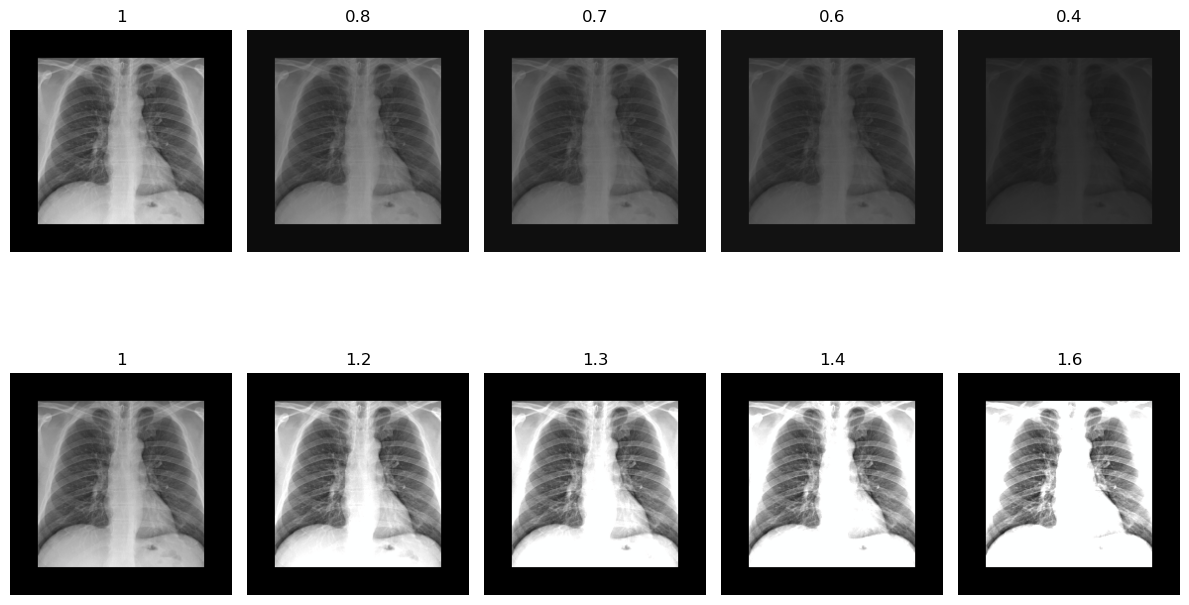

In [ ]:
img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.2, 0.3, 0.4, 0.6]
values = [1 - s for s in strengths] + [1 + s for s in strengths]
transform = lambda x, v: F.adjust_brightness(F.adjust_contrast(x, v), v)
visualize_mn_mx_transform(img, transform, values)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


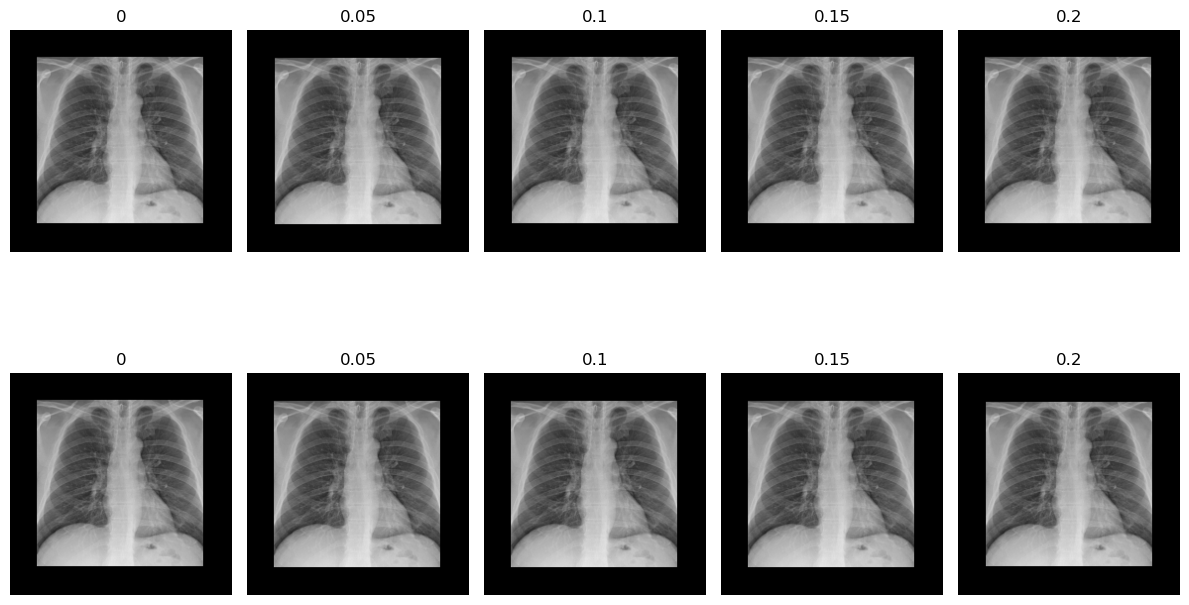

In [11]:
PADDING_INTENSITY = 0.25
import math 
from monai.transforms import RandSpatialCrop, SpatialPad
CROP_PAD_INTENSITY=0.1
def transform_crop_pad(img, intensity):
    return v2.Compose([
        RandSpatialCrop(roi_size=224*(1 - CROP_PAD_INTENSITY - intensity), max_roi_size=224*(1-CROP_PAD_INTENSITY), random_center=False, random_size=True),
        SpatialPad(spatial_size=(224, 224), mode="constant", constant_values=0),
    ])(img)

img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.05, 0.1, 0.15, 0.2]
values = strengths + strengths
visualize_mn_mx_transform(img, transform_crop_pad, values)

torch.Size([3, 224, 224])
torch.Size([3, 223, 223])
torch.Size([3, 224, 224])
torch.Size([3, 223, 223])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


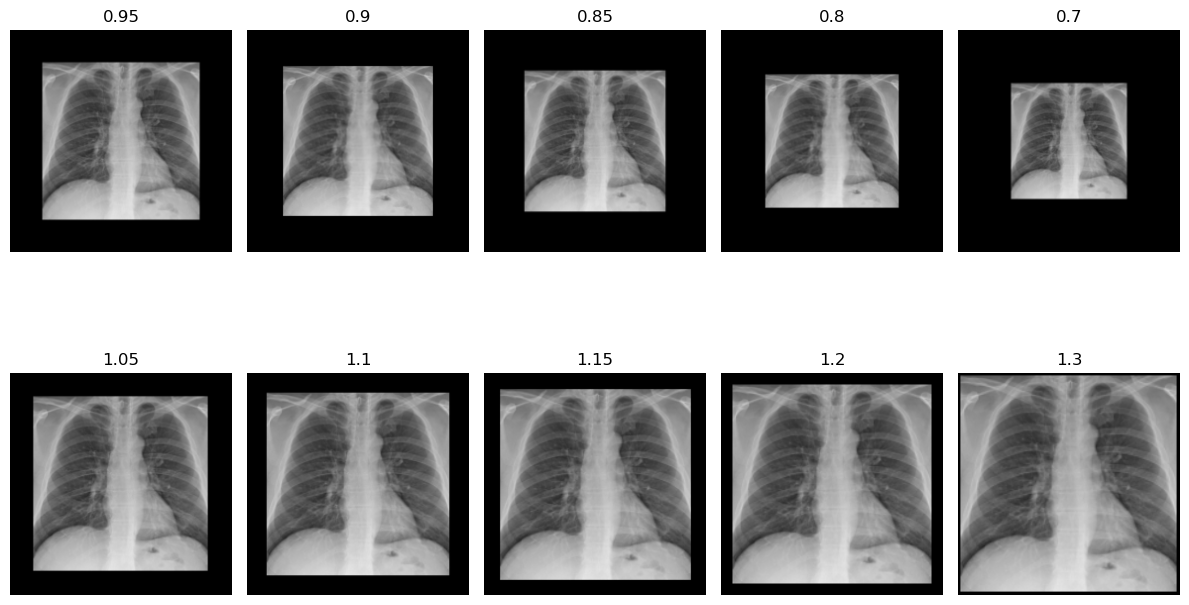

In [12]:
def transform_resize_crop_pad(img, scale):
    # Calculate new size after scaling
    new_size = int(224 * scale)
    
    # First resize the image
    resized = F.resize(img, [new_size, new_size])
    
    if scale < 1:
        # If scaled down, pad back to 224
        padding = (224 - new_size) // 2
        return v2.Pad(padding, fill=0)(resized)
    else:
        # If scaled up, center crop to 224
        return v2.CenterCrop(224)(resized)


img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0.05, 0.1, 0.15, 0.2, 0.3]
values = [1 - s for s in strengths] + [1 + s for s in strengths]
visualize_mn_mx_transform(img, transform_resize_crop_pad, values)


torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


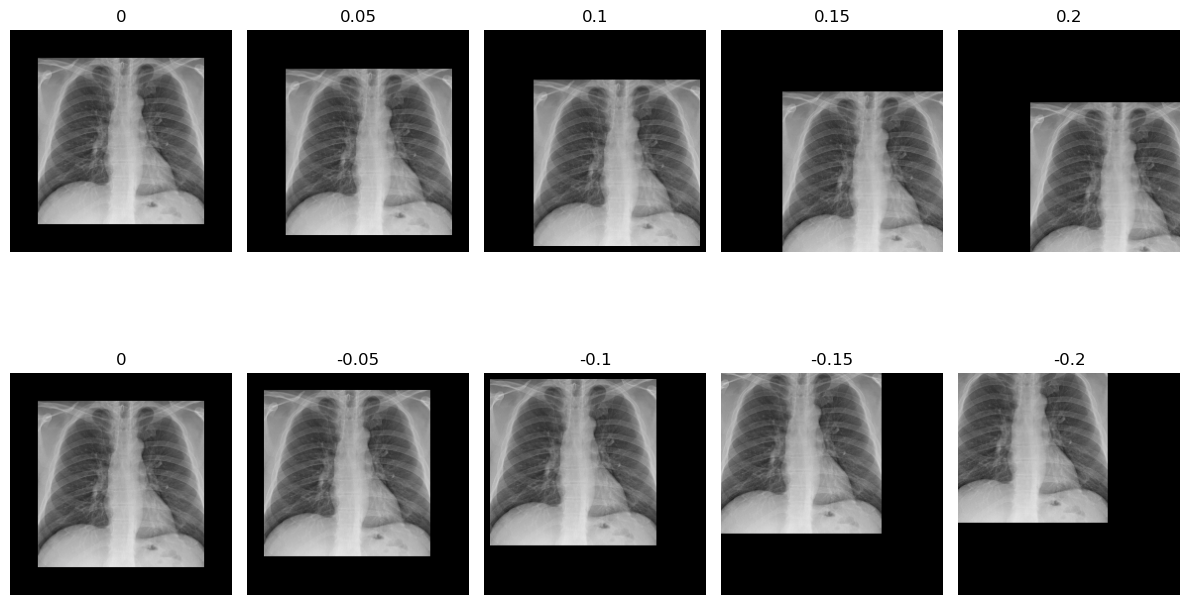

In [13]:
PADDING_INTENSITY = 0.25
import math 

def translation(img, intensity):
    return v2.Compose([
        v2.Lambda(lambda x: F.affine(x, 0, (intensity * 224, intensity * 224), 1, 0, 0, fill=0)),
    ])(img)

img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.05, 0.1, 0.15, 0.2]
values = strengths + [-s for s in strengths]
visualize_mn_mx_transform(img, translation, values)

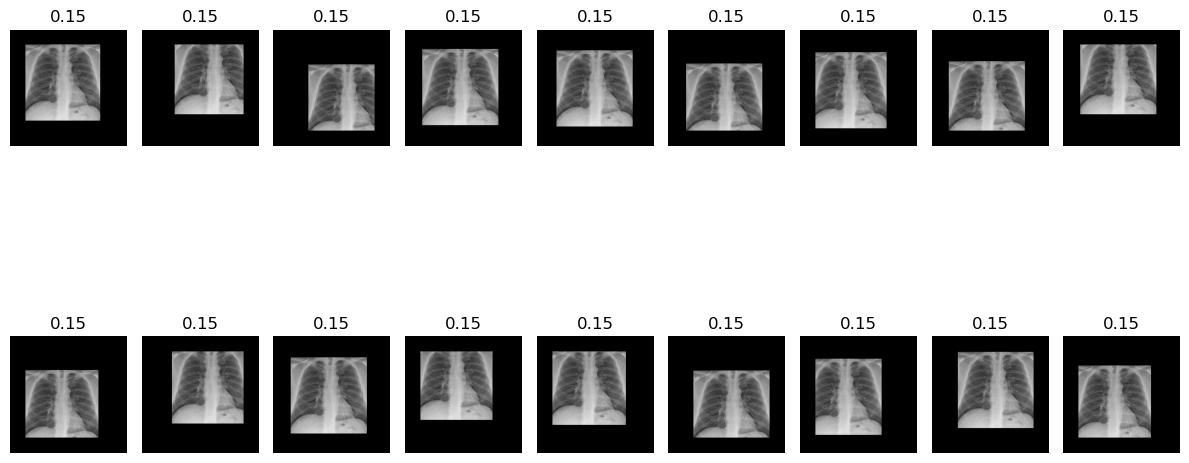

In [14]:
from utils import get_preprocessing
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from torchvision.transforms import v2

def visualize_random_transform(img, transform, intensity, repeats):
    fig, axes = plt.subplots(2, repeats // 2, figsize=(12, 8))
    axes = axes.ravel()

    # Get preprocessing transform
    preprocessing = get_preprocessing("crop_pad-0.75")

    # Show images from different datasets
    for i in range(repeats):
        img, _, _, _ = pos_ds.__getitem__(0)
        img = preprocessing(img)
        img = transform(img)
        show_image(img, intensity, axes[i])

    plt.tight_layout()

img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.05, 0.1, 0.15, 0.2]
values = strengths + [-s for s in strengths]
visualize_random_transform(img, lambda x: random_crop_by_translation(0.15, 0.15)(x), 0.15, 18)

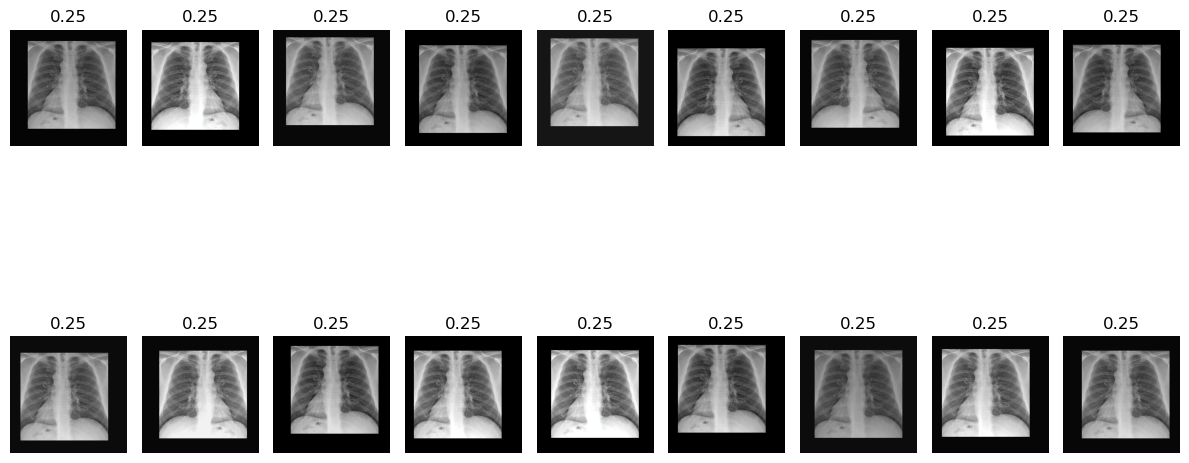

In [16]:
img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.05, 0.1, 0.15, 0.2]
values = strengths + [-s for s in strengths]
visualize_random_transform(img, AUGMENTATION_SETUP["random_crop-strong-forced"], 0.25, 18)

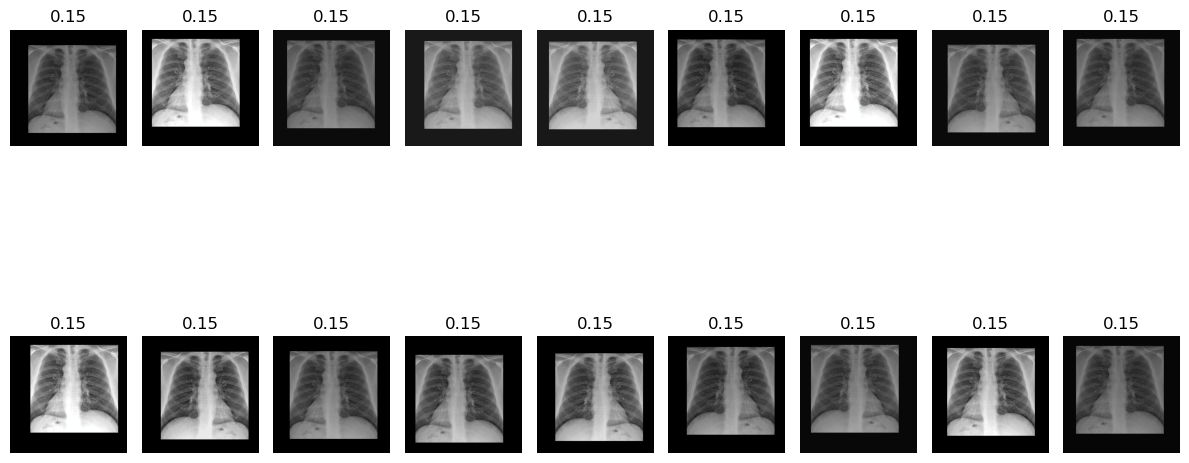

In [19]:
img, y, _, _ = pos_ds.__getitem__(0)
strengths = [0, 0.05, 0.1, 0.15, 0.2]
values = strengths + [-s for s in strengths]
visualize_random_transform(img, AUGMENTATION_SETUP["baseline-augments"], 0.15, 18)